# MNIST MLP: Model Analysis

This notebook provides a detailed analysis of various experimental phases conducted to understand the behavior of Multi-layer Perceptrons (MLPs) on the MNIST dataset.

## Phases covered:
1. **Architecture Analysis**: Depth vs. Width impact.
2. **Activation Functions**: ReLU, GELU, Sigmoid, Tanh, LeakyReLU.
3. **Dropout**: Regularization and Overfitting control.
4. **Batch Normalization (BN)**: Placement and Impact on convergence.
5. **Regularization (L1/L2)**: Sparsity and Generalization.
6. **Training Framework**: Learning Rates and Schedulers.
7. **Extended Model Analysis**: t-SNE visualization, Misclassification, Confidence Interval, Weight Distribution

In [1]:
import torch, os, numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

def load_phase_data(path):
    if not os.path.exists(path): return {}, {}
    hists = {f[:-12]: torch.load(f"{path}/{f}") for f in os.listdir(path) if f.endswith('_history.pth')}
    tests = {f[:-9]: torch.load(f"{path}/{f}") for f in os.listdir(path) if f.endswith('_test.pth')}
    return hists, tests

mapping = {
    'p1': 'phase1', 'p2': 'phase2_act', 'p3': 'phase3_dropout',
    'p4': 'phase2_bn', 'p5': 'phase3_reg', 'p6': 'phase4_scheduler',
    'p7': 'phase4_lr', 'p8': 'phase4_patience'
}

for prefix, folder in mapping.items():
    h, t = load_phase_data(f'experiments/results/{folder}')
    globals()[f"{prefix}_hist"], globals()[f"{prefix}_test"] = h, t

data = {
    'architecture': (p1_hist, p1_test),
    'activations': (p2_hist, p2_test),
    'dropout': (p3_hist, p3_test),
    'batchnorm': (p4_hist, p4_test),
    'regularization': (p5_hist, p5_test),
    'framework_sched': (p6_hist, p6_test),
    'framework_lr': (p7_hist, p7_test),
    'framework_patience': (p8_hist, p8_test)
}

In [2]:
all_results = [
    {'Model': name, 'Accuracy': res.get('accuracy', 0)}
    for phase in data.values() 
    for name, res in phase[1].items()
]

df_top = pd.DataFrame(all_results).sort_values('Accuracy', ascending=False)
display(df_top.head(10))

,Model,Accuracy
50,sched_cosine,0.9855
52,sched_exp,0.9842
28,gelu,0.9836
32,dropout_0.4,0.9834
41,L1_1e-5,0.9832
58,patience_10,0.9827
35,bn_before,0.9827
47,L2_1e-4,0.9827
49,sched_step,0.9827
60,patience_20,0.9827


## 1. Analyze the impact of the MLP architecture
Testing impact of Depth (1-6 layers) and Width (128-1024 neurons).

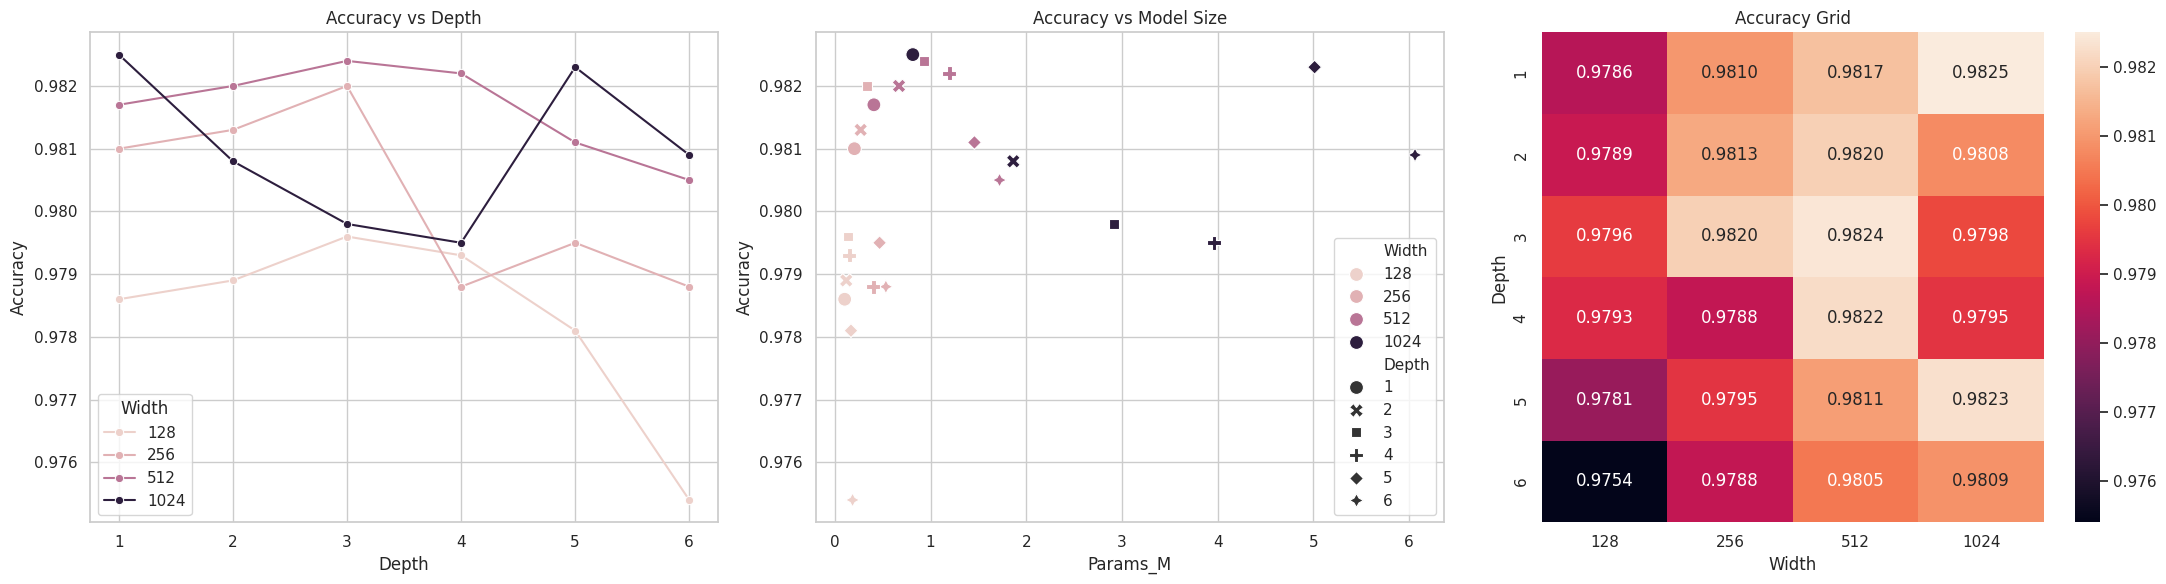

Best: Depth 1.0, Width 1024.0 (0.9825)
Params: 814,090


In [3]:
def count_params(d, w, i=784, c=10):
    # (input*w + w) + (hidden*w + w) + (w*classes + classes)
    return (i * w + w) + (d - 1) * (w * w + w) + (w * c + c)

records = [{
    'Depth': (d := int(n.split('_')[0][5:])),
    'Width': (w := int(n.split('_')[1][5:])),
    'Accuracy': r['accuracy'],
    'Params': (p := count_params(d, w)),
    'Params_M': p / 1e6
} for n, r in p1_test.items()]

df_arch = pd.DataFrame(records)

if not df_arch.empty:
    fig, ax = plt.subplots(1, 3, figsize=(22, 6))
    
    sns.lineplot(data=df_arch, x='Depth', y='Accuracy', hue='Width', marker='o', ax=ax[0])
    sns.scatterplot(data=df_arch, x='Params_M', y='Accuracy', hue='Width', style='Depth', s=100, ax=ax[1])
    sns.heatmap(df_arch.pivot(index="Depth", columns="Width", values="Accuracy"), annot=True, fmt=".4f", ax=ax[2])
    
    [a.set_title(t) for a, t in zip(ax, ['Accuracy vs Depth', 'Accuracy vs Model Size', 'Accuracy Grid'])]
    plt.tight_layout(); plt.show()

    best = df_arch.loc[df_arch['Accuracy'].idxmax()]
    print(f"Best: Depth {best.Depth}, Width {best.Width} ({best.Accuracy:.4f})\nParams: {int(best.Params):,}")

## 2. Analyze the impact of different activation functions

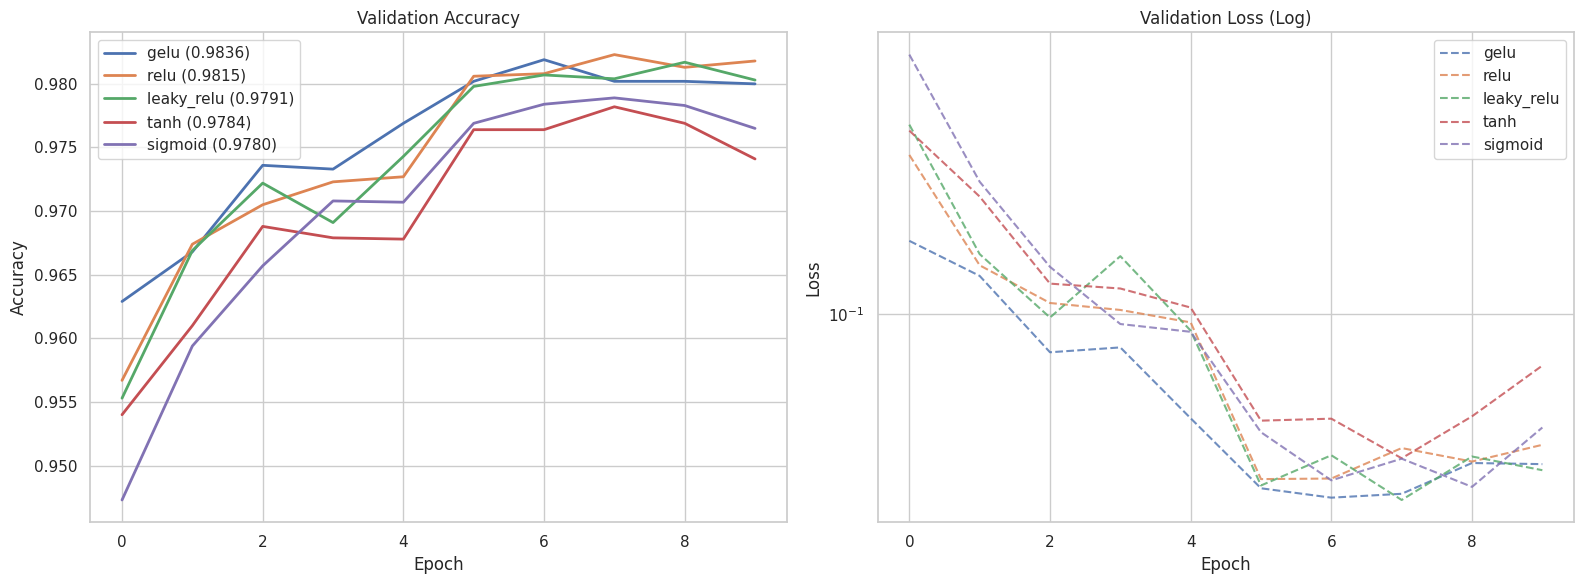

,Activation,Final Acc,Epoch to 95%
0,gelu,0.983600,0
1,relu,0.981500,0
2,leaky_relu,0.979100,0
3,tanh,0.978400,0
4,sigmoid,0.978000,1


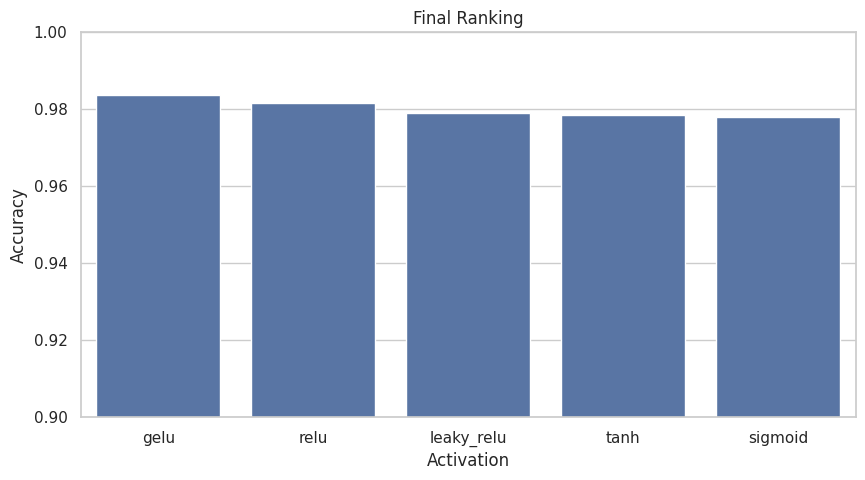

In [4]:
if p2_hist:
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    names = sorted(p2_test.keys(), key=lambda x: p2_test[x]['accuracy'], reverse=True)
    stats = []

    for n in names:
        h = p2_hist[n]
        ax[0].plot(h['val_acc'], label=f"{n} ({p2_test[n]['accuracy']:.4f})", lw=2)
        ax[1].plot(h['val_loss'], label=n, ls='--', alpha=0.8)
        
        idx = np.where(np.array(h['val_acc']) >= 0.95)[0]
        stats.append({'Activation': n, 'Final Acc': p2_test[n]['accuracy'], 'Epoch to 95%': idx[0] if len(idx) > 0 else ">Max"})

    ax[0].set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    ax[1].set(title='Validation Loss (Log)', xlabel='Epoch', ylabel='Loss', yscale='log')
    [a.legend() for a in ax]; plt.tight_layout(); plt.show()

    display(pd.DataFrame(stats).style.background_gradient(subset=['Final Acc'], cmap='Greens'))

if p2_test:
    plt.figure(figsize=(10, 5))
    df_act = pd.DataFrame([{'Activation': k, 'Accuracy': v['accuracy']} for k, v in p2_test.items()])
    sns.barplot(data=df_act.sort_values('Accuracy', ascending=False), x='Activation', y='Accuracy')
    plt.ylim(0.9, 1.0); plt.title('Final Ranking'); plt.show()

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from mlp_model import MLP
from parameters import ModelConfig

def get_test_loader(batch_size=1000):
    t = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    return DataLoader(datasets.MNIST('./data', train=False, download=True, transform=t), batch_size=batch_size)

def get_embeddings(model, loader):
    model.eval()
    embeds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            x = model.flatten(imgs)
            for layer in model.layers: x = layer(x) # Safe layer iteration
            embeds.append(x.numpy()); labels.append(lbls.numpy())
    return np.concatenate(embeds), np.concatenate(labels)

Calculating t-SNE for: relu
Calculating t-SNE for: leaky_relu
Calculating t-SNE for: gelu
Calculating t-SNE for: sigmoid
Calculating t-SNE for: tanh


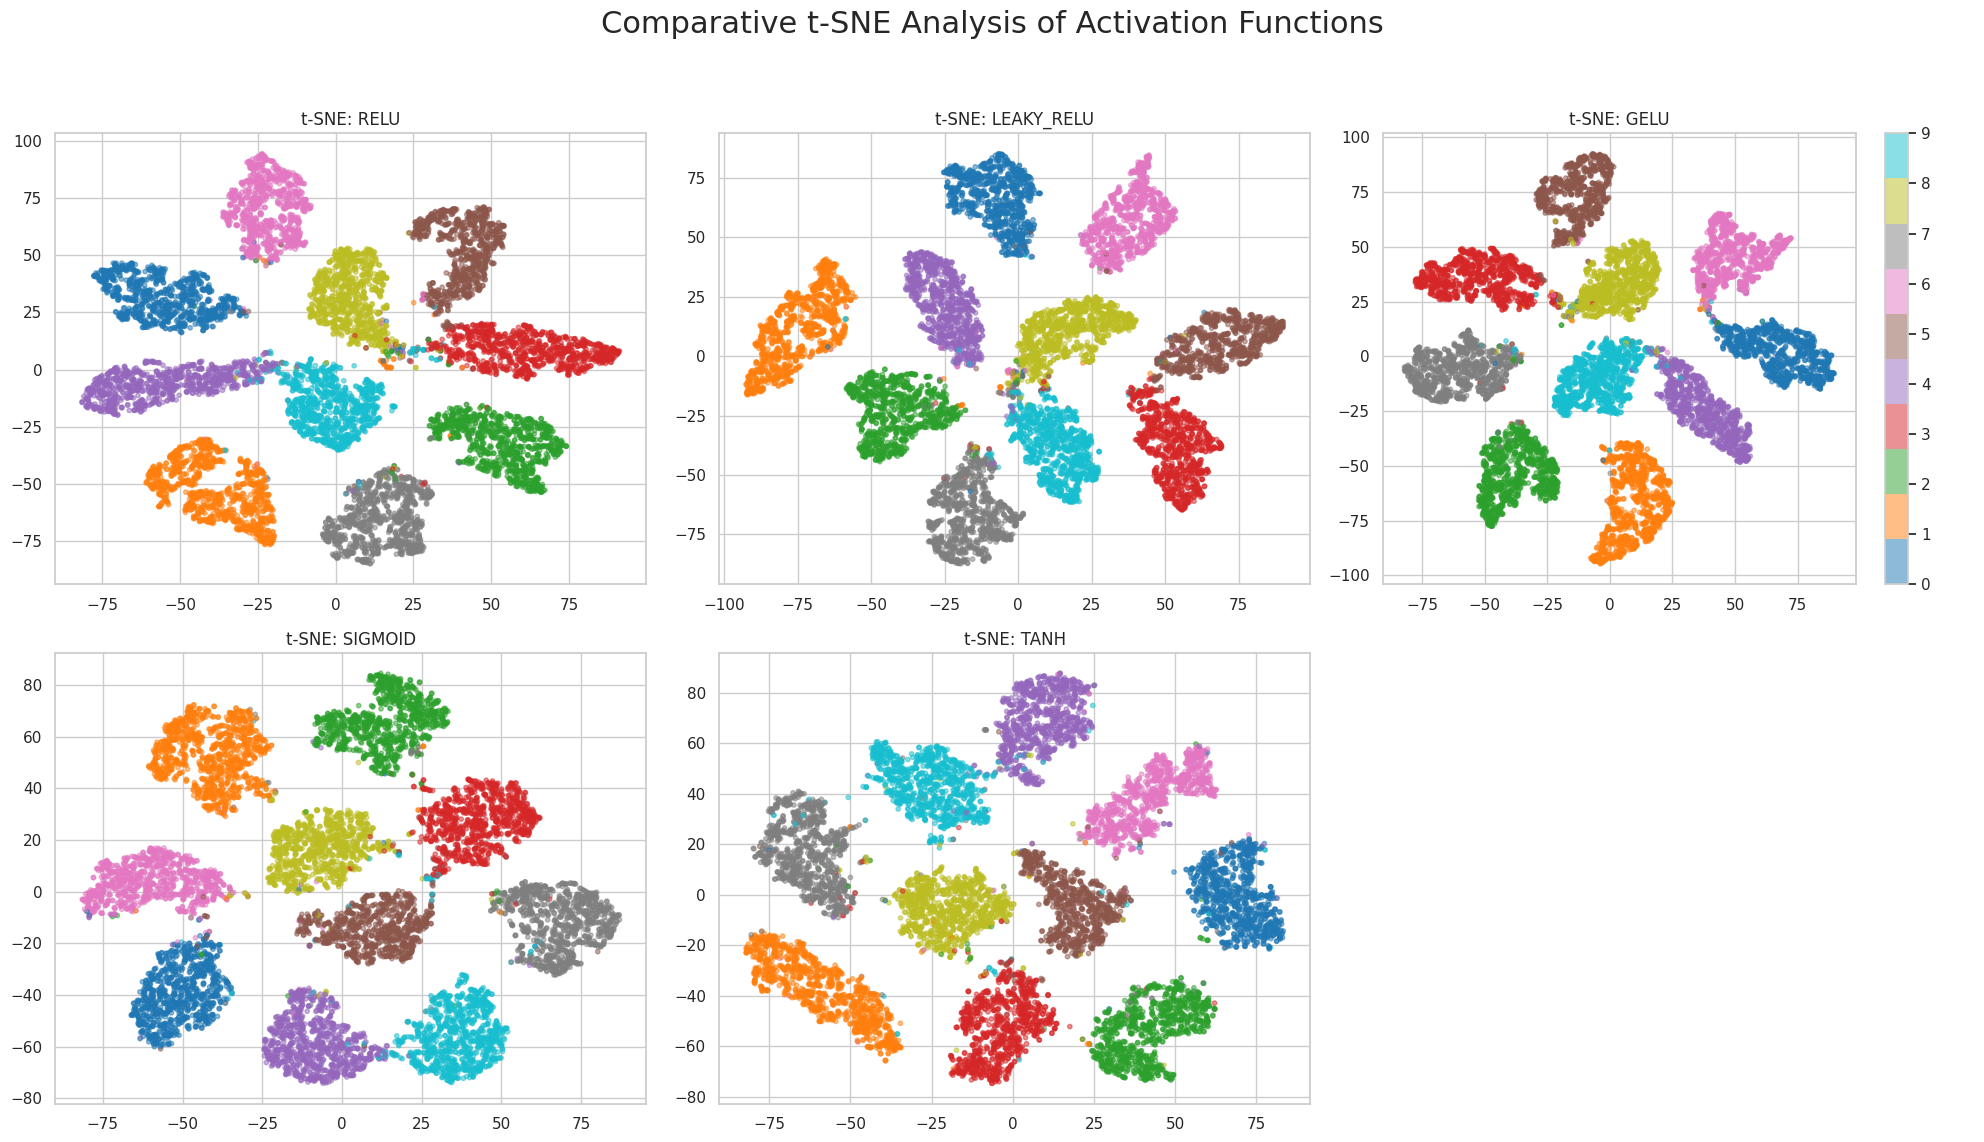

In [6]:
acts = ['relu', 'leaky_relu', 'gelu', 'sigmoid', 'tanh']
loader = get_test_loader(batch_size=1500)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, act in enumerate(acts):
    path = f'experiments/models/{act}.pth'
    if os.path.exists(path):
        m = MLP(ModelConfig(activation=act, hidden_sizes=[512]*3, use_batchnorm=False)).eval()
        try:
            m.load_state_dict(torch.load(path, map_location='cpu'))
            print(f"Calculating t-SNE for: {act}")
            embeds, lbls = get_embeddings(m, loader)
            red = TSNE(random_state=42).fit_transform(embeds)
            
            sc = axes[i].scatter(red[:, 0], red[:, 1], c=lbls, cmap='tab10', alpha=0.5, s=10)
            axes[i].set_title(f"t-SNE: {act.upper()}")
            if i == 2: fig.colorbar(sc, ax=axes[i], ticks=range(10))
        except Exception: axes[i].text(0.5, 0.5, f"Error: {act}", ha='center')
    else: axes[i].text(0.5, 0.5, f"Missing: {act}.pth", ha='center')

axes[5].axis('off')
plt.suptitle("Comparative t-SNE Analysis of Activation Functions", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

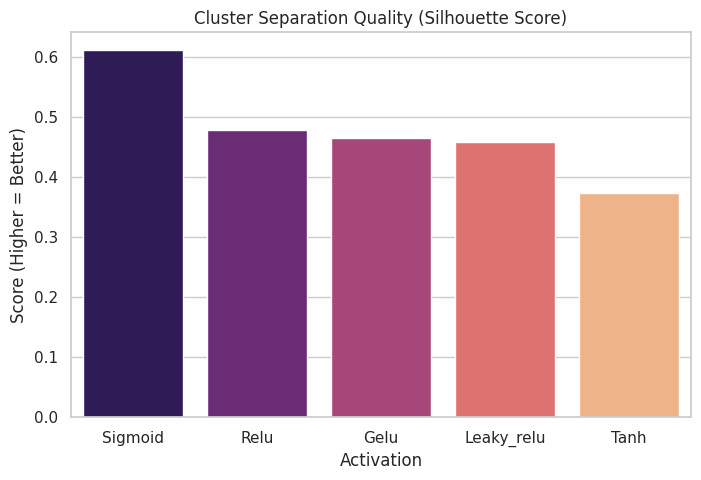

Silhouette Leaderboard:
Activation    Score
   Sigmoid 0.610254
      Relu 0.477497
      Gelu 0.463810
Leaky_relu 0.457533
      Tanh 0.372816


In [7]:
from sklearn.metrics import silhouette_score

loader = get_test_loader(2000)
sil_res = []

for act in ['gelu', 'leaky_relu', 'relu', 'sigmoid', 'tanh']:
    path = f'experiments/models/{act}.pth'
    if os.path.exists(path):
        m = MLP(ModelConfig(activation=act, hidden_sizes=[512]*3, use_batchnorm=False)).eval()
        m.load_state_dict(torch.load(path, map_location='cpu'))
        
        embeds, labels = get_embeddings(m, loader)
        sil_res.append({'Activation': act.capitalize(), 'Score': silhouette_score(embeds, labels)})

df_sil = pd.DataFrame(sil_res).sort_values('Score', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_sil, x='Activation', y='Score', hue='Activation', palette='magma', legend=False)
plt.title('Cluster Separation Quality (Silhouette Score)')
plt.ylabel('Score (Higher = Better)'); plt.show()

print(f"Silhouette Leaderboard:\n{df_sil.to_string(index=False)}")

## 3. Analyze the impact of the dropout module

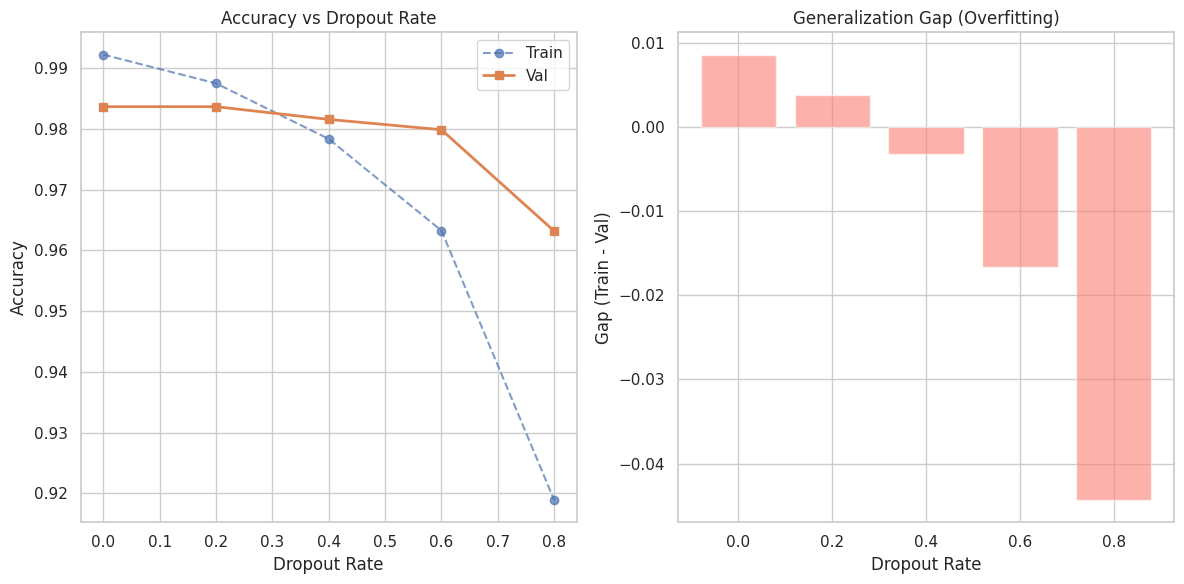

In [9]:
df_drop = pd.DataFrame([{
    'Dropout': float(n.split('_')[1]), 
    'Train': h['train_acc'][-1], 
    'Val': h['val_acc'][-1]
} for n, h in p3_hist.items()]).sort_values('Dropout')

df_drop['Gap'] = df_drop['Train'] - df_drop['Val']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Accuracy
ax[0].plot(df_drop.Dropout, df_drop.Train, 'o--', label='Train', alpha=0.7)
ax[0].plot(df_drop.Dropout, df_drop.Val, 's-', label='Val', lw=2)
ax[0].set(title='Accuracy vs Dropout Rate', xlabel='Dropout Rate', ylabel='Accuracy')
ax[0].legend()

# Subplot 2: Generalization Gap
ax[1].bar(df_drop.Dropout.astype(str), df_drop.Gap, color='salmon', alpha=0.6)
ax[1].set(title='Generalization Gap (Overfitting)', xlabel='Dropout Rate', ylabel='Gap (Train - Val)')

plt.tight_layout(); plt.show()

## 4. Analyze the impact of trainning framework

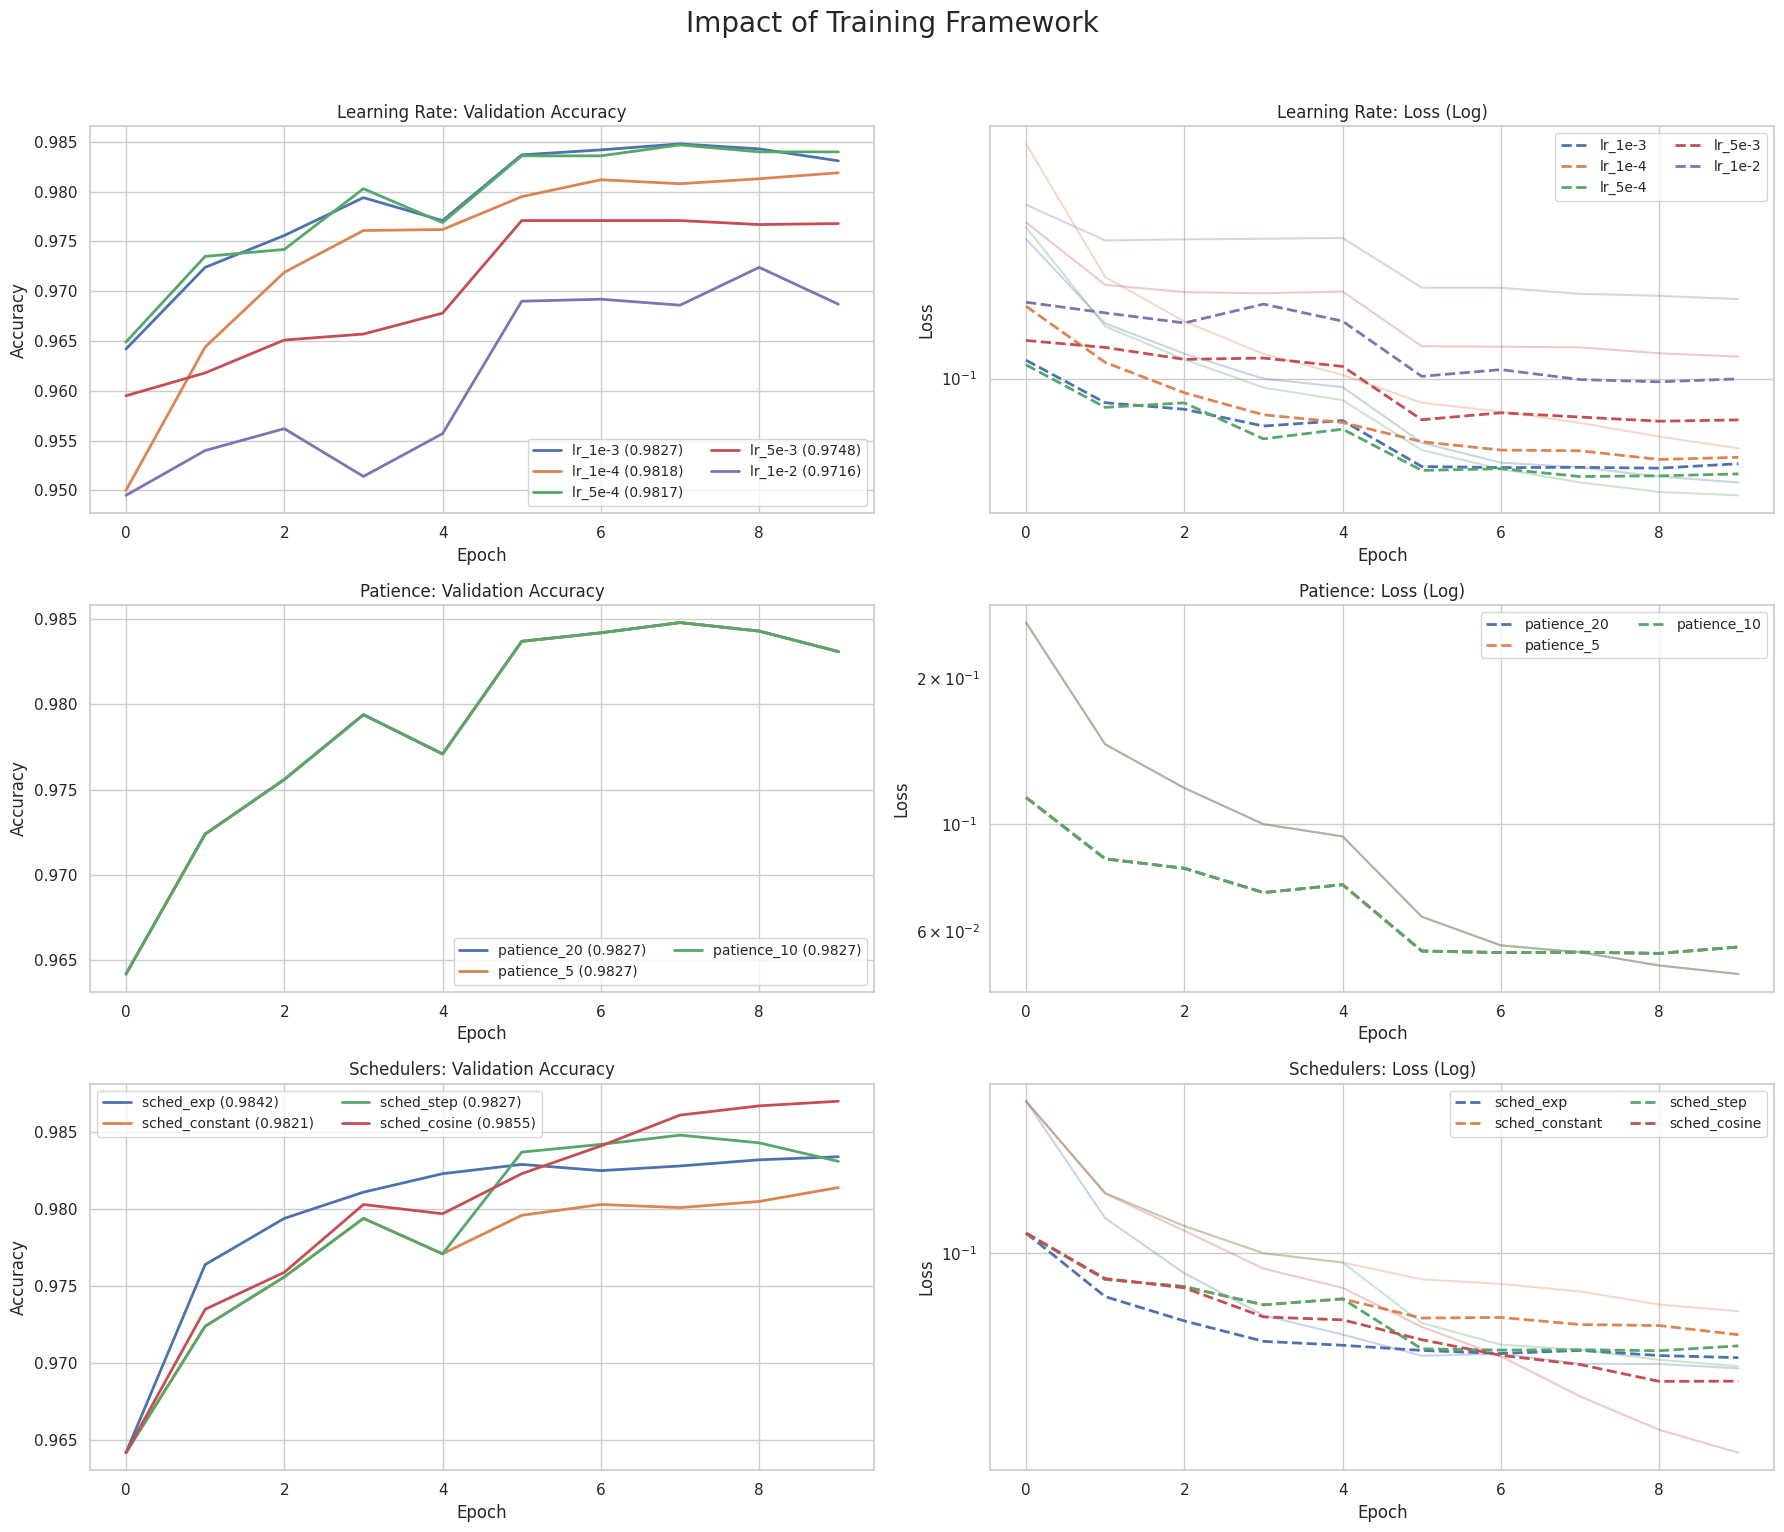

In [11]:
framework_map = {
    'Learning Rate': 'framework_lr',
    'Patience': 'framework_patience',
    'Schedulers': 'framework_sched'
}

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

for i, (label, key) in enumerate(framework_map.items()):
    hist_dict, test_dict = data[key]
    ax0, ax1 = axes[i, 0], axes[i, 1]
    
    for name, h in hist_dict.items():
        acc = test_dict.get(name, {}).get('accuracy', 0)
        
        # Left: Validation Accuracy
        ax0.plot(h['val_acc'], label=f"{name} ({acc:.4f})", lw=2)
        
        # Right: Train/Val Loss
        c = ax1.plot(h['train_loss'], alpha=0.3)[0].get_color()
        ax1.plot(h['val_loss'], label=name, color=c, lw=2, ls='--')

    ax0.set(title=f'{label}: Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    ax1.set(title=f'{label}: Loss (Log)', xlabel='Epoch', ylabel='Loss', yscale='log')
    ax0.legend(fontsize='small', ncol=2); ax1.legend(fontsize='small', ncol=2)

plt.suptitle("Impact of Training Framework", fontsize=20, y=1.02)
plt.tight_layout(); plt.show()

## 5. Analyze the impact of BN layer

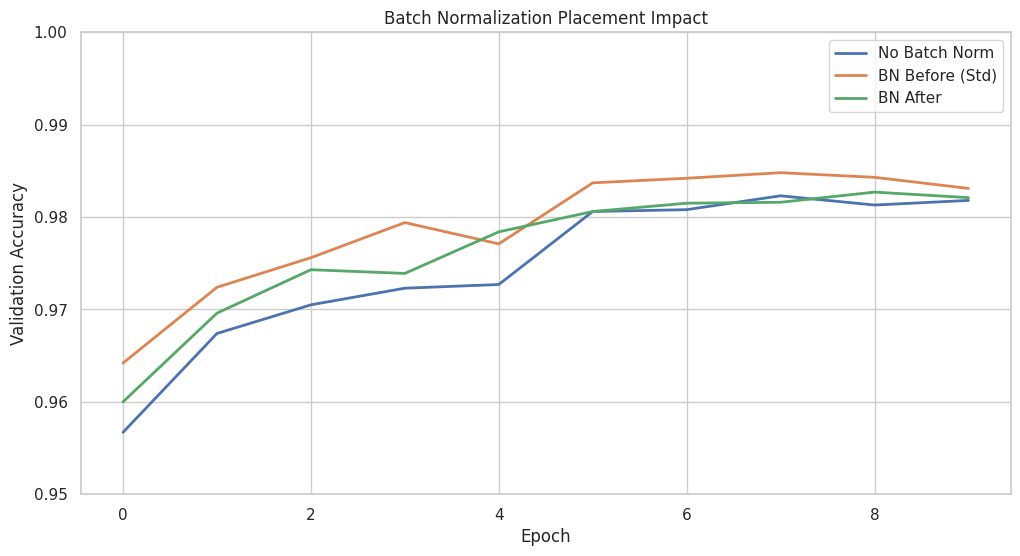

Experiment      | Accuracy
----------------------------
no_bn           | 0.9815
bn_before       | 0.9827
bn_after        | 0.9792


In [12]:
exps = {'no_bn': 'No Batch Norm', 'bn_before': 'BN Before (Std)', 'bn_after': 'BN After'}

plt.figure(figsize=(12, 6))
for k, lbl in exps.items():
    if k in p4_hist: plt.plot(p4_hist[k]['val_acc'], label=lbl, lw=2)

plt.title('Batch Normalization Placement Impact')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.ylim(0.95, 1.0)
plt.legend(); plt.show()

print(f"{'Experiment':<15} | Accuracy\n" + "-" * 28)
for k in exps:
    if k in p4_test: print(f"{k:<15} | {p4_test[k]['accuracy']:.4f}")

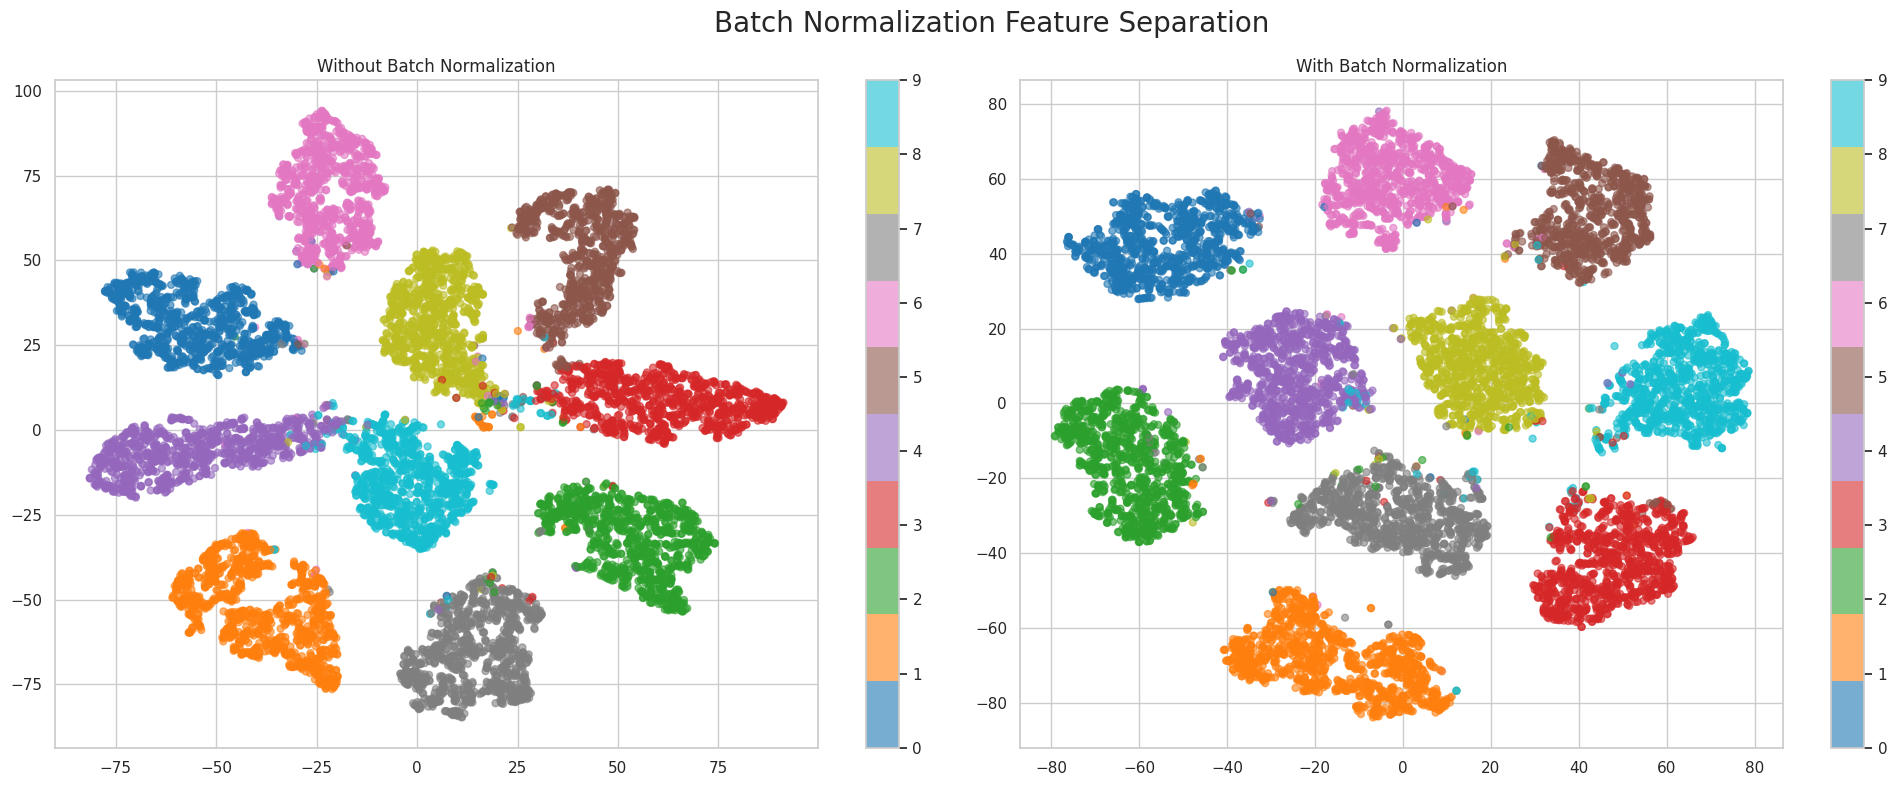

In [13]:
loader = get_test_loader(1500)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
models = [('no_bn', False, 'Without Batch Normalization'), 
          ('bn_before', True, 'With Batch Normalization')]

for i, (name, bn, title) in enumerate(models):
    path = f'experiments/models/{name}.pth'
    if os.path.exists(path):
        m = MLP(ModelConfig(hidden_sizes=[512]*3, use_batchnorm=bn)).eval()
        m.load_state_dict(torch.load(path, map_location='cpu'))        
        embeds, lbls = get_embeddings(m, loader) 
        red = TSNE(random_state=42).fit_transform(embeds)
        sc = axes[i].scatter(red[:,0], red[:,1], c=lbls, cmap='tab10', alpha=0.6, s=25)
        axes[i].set_title(title)
        fig.colorbar(sc, ax=axes[i], ticks=range(10))
    else: 
        axes[i].text(0.5, 0.5, f"Missing: {name}.pth", ha='center')

plt.suptitle("Batch Normalization Feature Separation", fontsize=20); plt.tight_layout(); plt.show()

## 6. Analyze the impact of the regularizer term (L1 / L2) and the coefficient

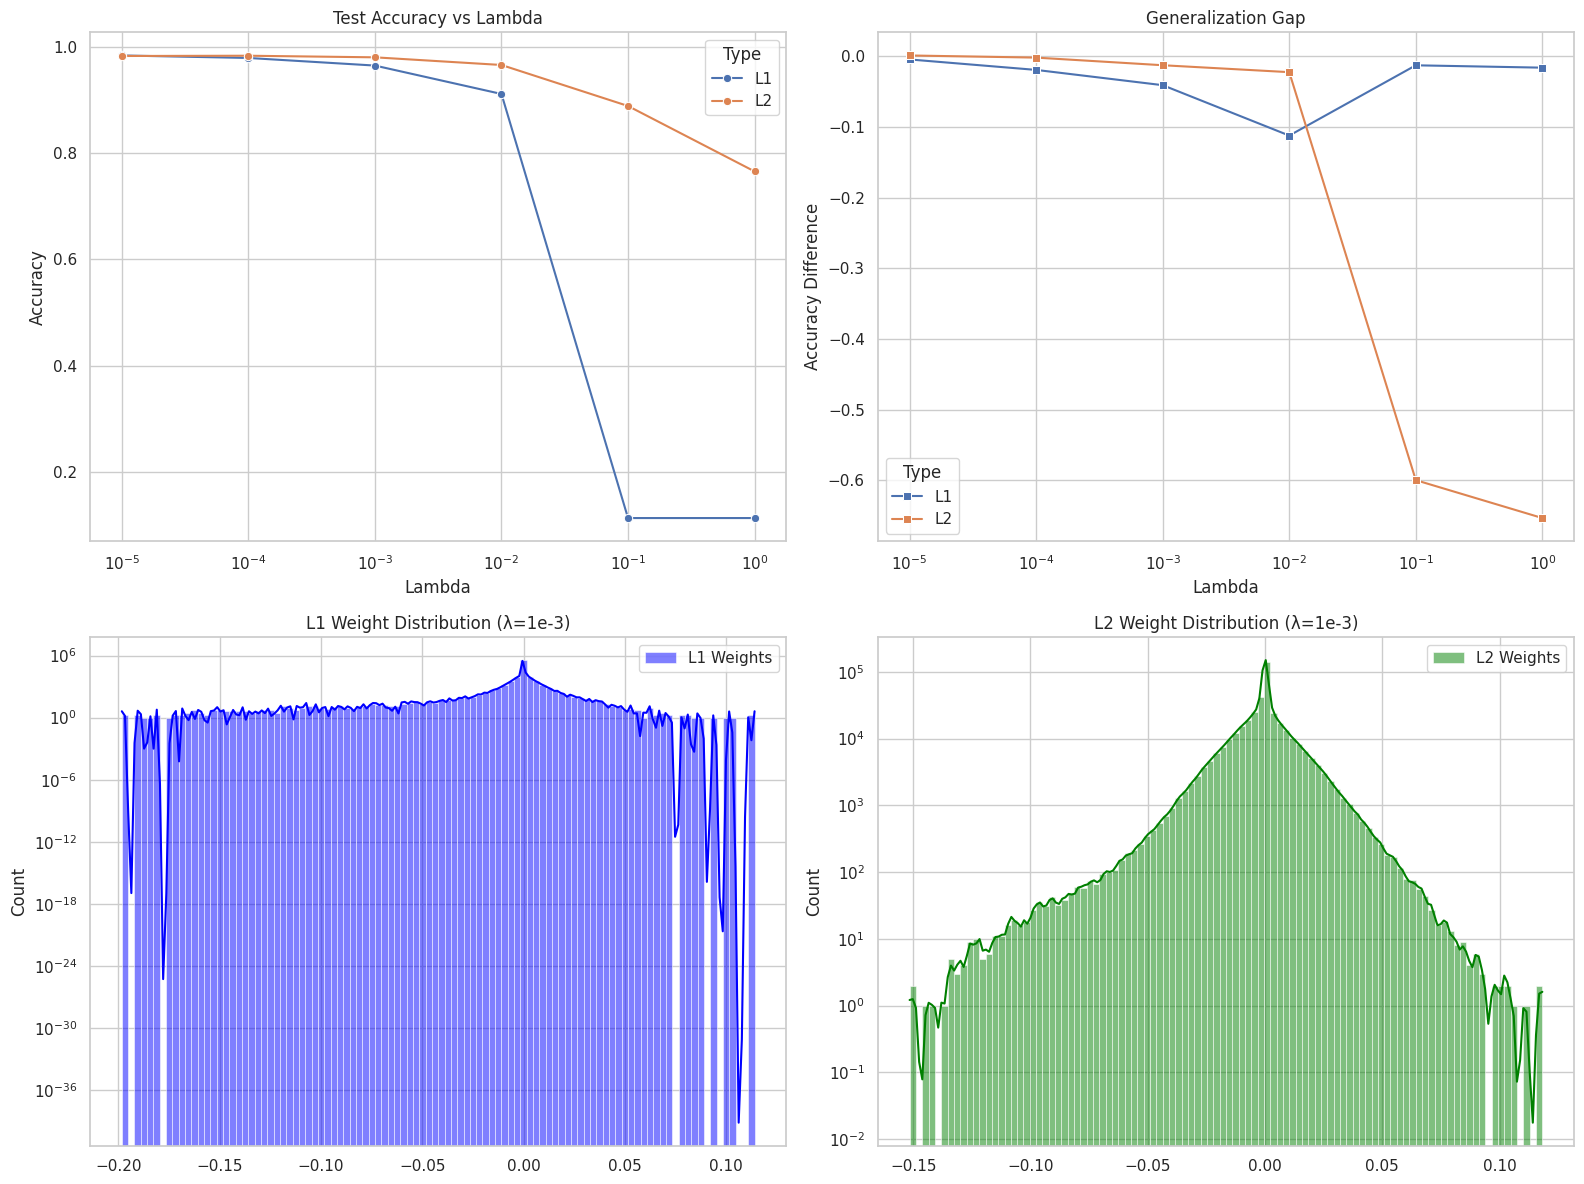

,Type,Lambda,Test_Accuracy,Gap
0,L1,0.00001,0.9832,-0.00470
1,L2,0.00010,0.9827,-0.00210
2,L2,0.00001,0.9822,0.00094
3,L2,0.00100,0.9797,-0.01288
4,L1,0.00010,0.9785,-0.01950
5,L2,0.01000,0.9653,-0.02268
6,L1,0.00100,0.9642,-0.04110
7,L1,0.01000,0.9108,-0.11238
8,L2,0.10000,0.8882,-0.59980
9,L2,1.00000,0.7652,-0.65340


In [14]:
df = pd.DataFrame([{
    'Type': k.split('_')[0], 'Lambda': float(k.split('_')[1]),
    'Test_Accuracy': p5_test[k]['accuracy'],
    'Gap': h['train_acc'][-1] - p5_test[k]['accuracy']
} for k, h in p5_hist.items()]).sort_values('Lambda')

fig, ax = plt.subplots(2, 2, figsize=(16, 12))

sns.lineplot(data=df, x='Lambda', y='Test_Accuracy', hue='Type', marker='o', ax=ax[0, 0])
ax[0, 0].set(xscale='log', title='Test Accuracy vs Lambda', ylabel='Accuracy')

sns.lineplot(data=df, x='Lambda', y='Gap', hue='Type', marker='s', ax=ax[0, 1])
ax[0, 1].set(xscale='log', title='Generalization Gap', ylabel='Accuracy Difference')

lam = "1e-3"
for i, typ in enumerate(['L1', 'L2']):
    state = torch.load(f"experiments/models/{typ}_{lam}.pth", map_location='cpu')
    w = next(v.flatten().numpy() for k, v in state.items() if 'weight' in k)
    
    sns.histplot(w, bins=100, color='blue' if typ == 'L1' else 'green', alpha=0.5, label=f'{typ} Weights', ax=ax[1, i], kde=True)
    ax[1, i].set(title=f'{typ} Weight Distribution (λ={lam})', yscale='log')
    ax[1, i].legend()

plt.tight_layout(); plt.show()
display(df.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True))

## 7. Extended Analysis
Using the best model

### 7.1 Confidence Dist. & Missclassification & Confusion Matrix

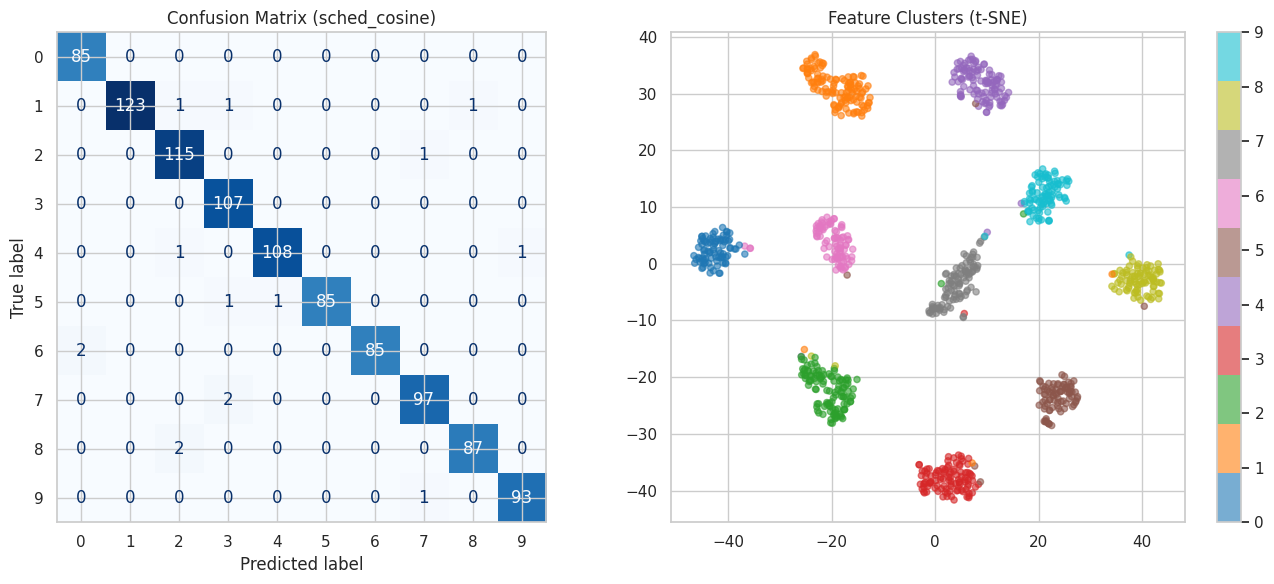

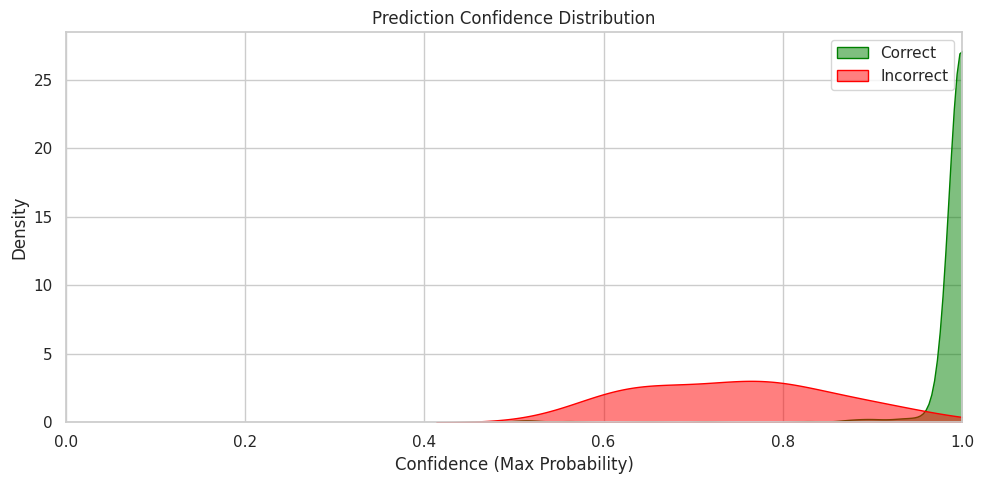

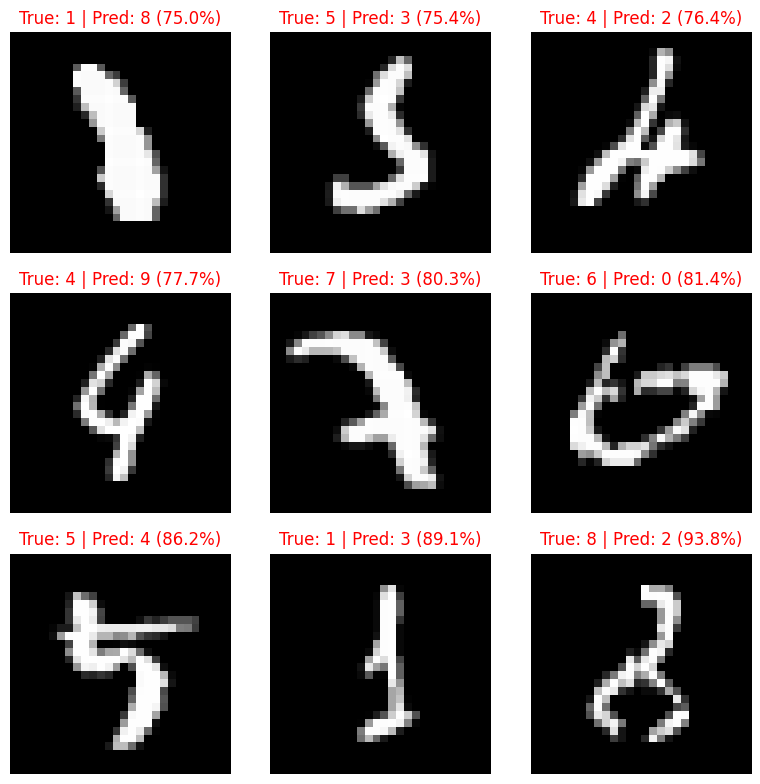

In [15]:
import torch.nn.functional as F

name = 'sched_cosine'
n = 1000

h = [512]*3 if any(m in name for m in ['relu', 'sigmoid', 'tanh', 'sched']) else [512, 256, 128]
bn = 'sched' in name or not any(m in name for m in ['relu', 'sigmoid', 'tanh', 'sched'])

# handle batch norm
m = MLP(ModelConfig(hidden_sizes=h, use_batchnorm=bn)).eval()
try: 
    m.load_state_dict(torch.load(f'experiments/models/{name}.pth', map_location='cpu'))
except RuntimeError: 
    m = MLP(ModelConfig(hidden_sizes=h, use_batchnorm=bn, bn_before_activation=False)).eval()
    m.load_state_dict(torch.load(f'experiments/models/{name}.pth', map_location='cpu'))

imgs, lbls = next(iter(get_test_loader(n)))
with torch.no_grad():
    x = m.flatten(imgs)
    for i, layer in enumerate(m.layers): 
        x = layer(x)
        if i == len(m.layers) - 1: embeds = x.numpy()
    
    logits = m.output_layer(x)
    probs = F.softmax(logits, dim=1).numpy()
    preds = logits.argmax(1).numpy()
    labels = lbls.numpy()

conf = probs.max(axis=1)
correct = preds == labels
incorrect = ~correct

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(labels, preds, cmap='Blues', colorbar=False, ax=ax[0])
ax[0].set_title(f'Confusion Matrix ({name})')

red = TSNE(random_state=42).fit_transform(embeds)
sc = ax[1].scatter(red[:,0], red[:,1], c=labels, cmap='tab10', alpha=0.6, s=20)
fig.colorbar(sc, ax=ax[1], ticks=range(10))
ax[1].set_title('Feature Clusters (t-SNE)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(conf[correct], fill=True, label='Correct', color='green', alpha=0.5)
if incorrect.any():
    sns.kdeplot(conf[incorrect], fill=True, label='Incorrect', color='red', alpha=0.5)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence (Max Probability)'); plt.ylabel('Density')
plt.xlim(0, 1); plt.legend()
plt.tight_layout(); plt.show()


errs = np.where(incorrect)[0]
if len(errs) > 0:
    top_errs = errs[np.argsort(conf[errs])[-min(9, len(errs)):]]
    fig, ax = plt.subplots(3, 3, figsize=(8, 8))
    for i, idx in enumerate(top_errs):
        ax.flat[i].imshow(imgs[idx].squeeze(), cmap='gray')
        ax.flat[i].set_title(f"True: {labels[idx]} | Pred: {preds[idx]} ({conf[idx]:.1%})", color='red')
    [a.axis('off') for a in ax.flat] 
    plt.tight_layout(); plt.show()

### 7.2 NN Model Visualization

Default architecture: [512, 256, 128]


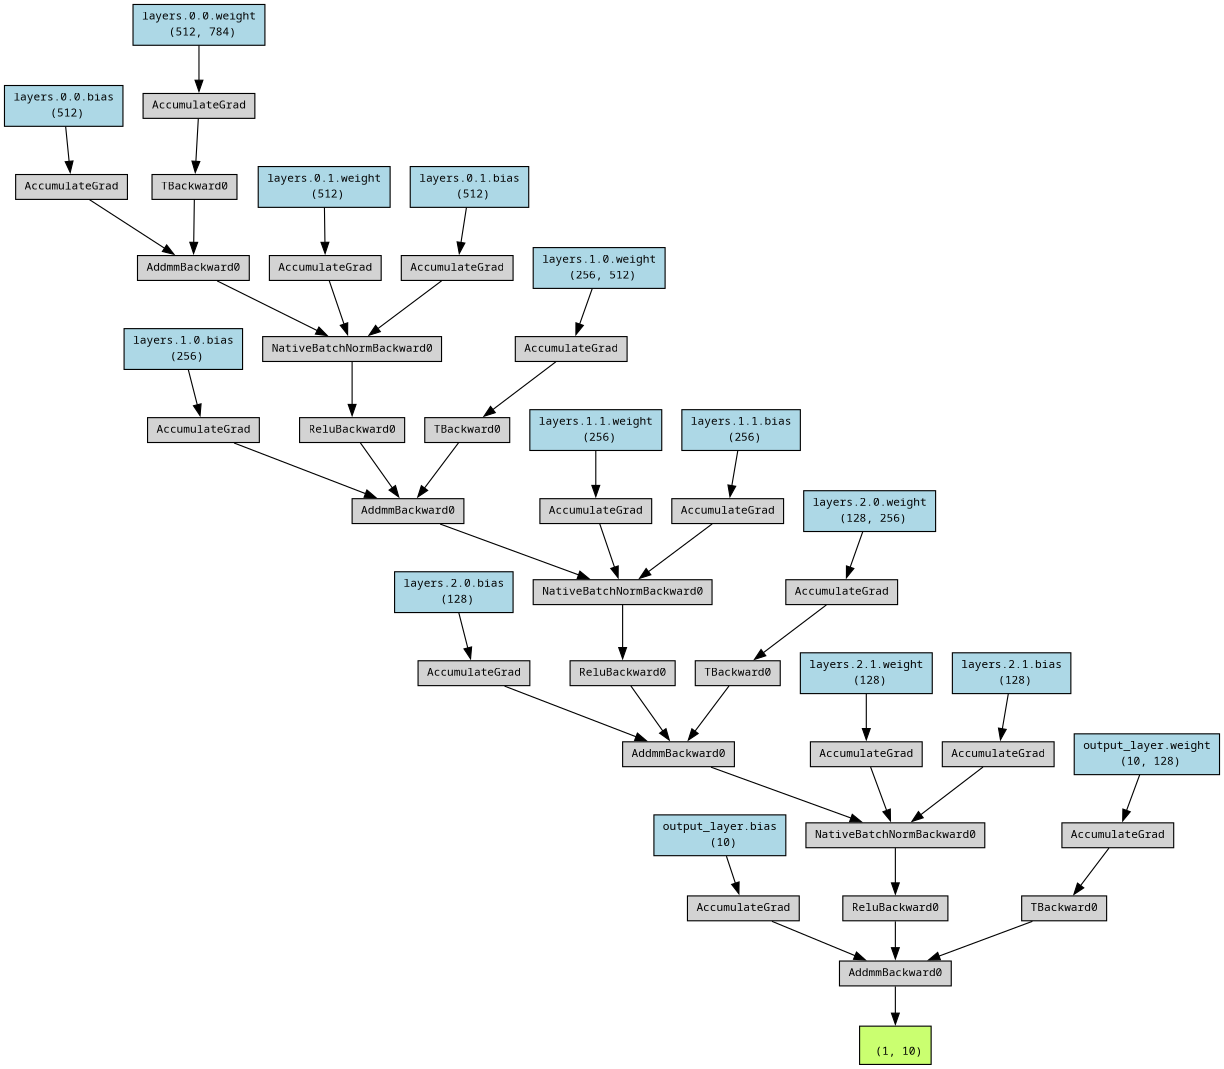

In [16]:
from torchviz import make_dot
from IPython.display import Image, display

# visualizing the architecture as defined in the code defaults
config = ModelConfig() 
model = MLP(config).to('cpu')
model.eval() 

print(f"Default architecture: {config.hidden_sizes}")

# creating the graph
dummy_input = torch.randn(1, 1, 28, 28)
y = model(dummy_input)
dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = 'png'

os.makedirs('images', exist_ok=True)
viz_path = 'images/model_viz'
dot.render(viz_path)
display(Image(f"{viz_path}.png"))

### 7.3 Weight Distributions

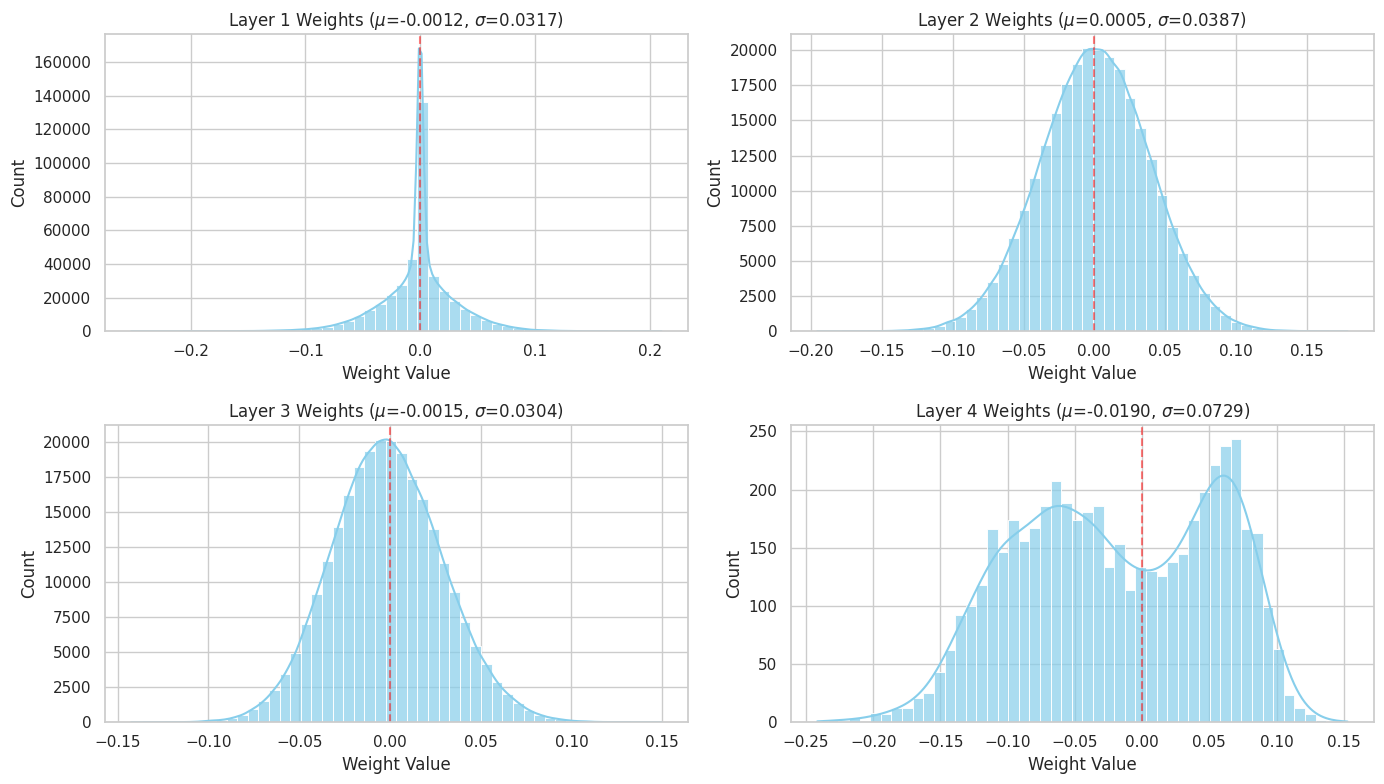

In [17]:
import torch.nn as nn

name = 'sched_cosine'
h = [512, 512, 512]
bn = True

m = MLP(ModelConfig(hidden_sizes=h, use_batchnorm=bn)).eval()
try: 
    m.load_state_dict(torch.load(f'experiments/models/{name}.pth', map_location='cpu'))
except RuntimeError: 
    m = MLP(ModelConfig(hidden_sizes=h, use_batchnorm=bn, bn_before_activation=False)).eval()
    m.load_state_dict(torch.load(f'experiments/models/{name}.pth', map_location='cpu'))

# Extract and plot linear layer weights
linears = [layer for layer in m.modules() if isinstance(layer, nn.Linear)]
rows = (len(linears) + 1) // 2

fig, ax = plt.subplots(rows, 2, figsize=(14, 4 * rows))
ax = np.atleast_1d(ax).flatten() 

for i, layer in enumerate(linears):
    w = layer.weight.detach().numpy().flatten()
    sns.histplot(w, bins=50, kde=True, color='skyblue', alpha=0.7, ax=ax[i])
    ax[i].axvline(0, color='red', ls='--', alpha=0.5)
    ax[i].set(title=f"Layer {i+1} Weights ($\mu$={w.mean():.4f}, $\sigma$={w.std():.4f})", xlabel="Weight Value")

for j in range(i + 1, len(ax)): ax[j].axis('off')
plt.tight_layout(); plt.show()